#### Experiment 1a
- 1D
- 5 electrodes - centre midline
- Average by linear PSD, log PSD and SpecMod.

In [1]:
# Imports for functionality 
from dissertation_simulations.eeg_data import avg_psd_distribution_2D_eeg
from dissertation_simulations.eeg_data import avg_specmod_distribution_2D_eeg
from dissertation_simulations.eeg_data import sweep_electrodes_psd_2D_eeg
from dissertation_simulations.eeg_data import sweep_electrodes_specmod_2D_eeg
from dissertation_simulations.plotting import plot_summary_boxplots

import numpy as np
import json

from scipy.stats import ttest_rel

Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_range: [2, 40]
Using freq_r

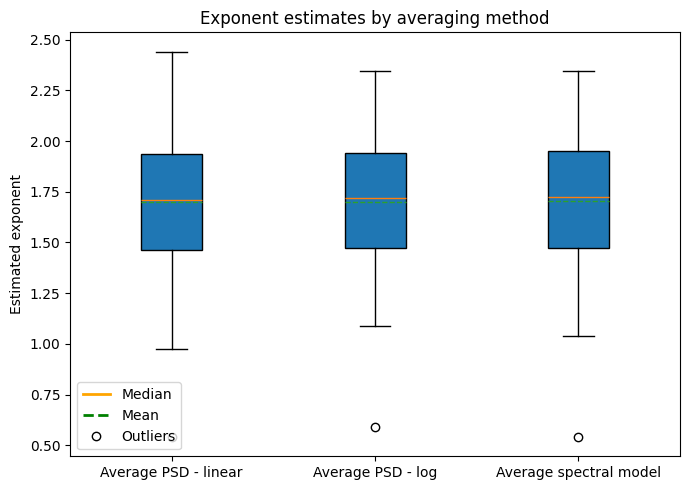

In [2]:
from pathlib import Path

data_dir = Path("/Users/chloe/DissertationSimulations/EEG data")

electrode_sweeps = [
    ["E11", "E6", "Cz", "E62", "E75"]
]

# Average the PSD - linear space
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec",
    psd_average_space = "linear", plot=False, return_full=True
)

exp1a_eeg_result1_psd_linear = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1aresults1_eeg_psd_linear_5elec_midline.json", "w") as f:
    json.dump(exp1a_eeg_result1_psd_linear, f, indent=4)

# Average the PSD - log space 
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec",
    psd_average_space = "log", plot=False, return_full=True
)

exp1a_eeg_result2_psd_log = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1aresults2_eeg_psd_log_5elec_midline.json", "w") as f:
    json.dump(exp1a_eeg_result2_psd_log, f, indent=4)

# Average the Spectral Model
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec", plot=False, return_full=True
)

exp1a_eeg_result3_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1aresults3_eeg_specmod_5elec_midline.json", "w") as f:
    json.dump(exp1a_eeg_result3_specmod, f, indent=4)

# Loading summaries and combining into a single plot
summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1aresults1_eeg_psd_linear_5elec_midline.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1aresults2_eeg_psd_log_5elec_midline.json", 
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1aresults3_eeg_specmod_5elec_midline.json"
]

labels = [
    "Average PSD - linear",
    "Average PSD - log", 
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\EEG data\exp1a_combined_plot_eeg_5elec_midline.png", dpi=300, bbox_inches="tight")

In [6]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1aresults1_eeg_psd_linear_5elec_midline.json") as f:
    psd_linear_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1aresults2_eeg_psd_log_5elec_midline.json") as f:
    psd_log_data = json.load(f)

with open (r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1aresults3_eeg_specmod_5elec_midline.json") as f:
    spec_data = json.load(f)

psd_linear = np.array(psd_linear_data["all_distributions"][0])
psd_log = np.array(psd_log_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(psd_linear, psd_log)
print(f"PSD - linear averaging vs PSD - log averaging: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_linear, spec)
print(f"PSD - linear averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_log, spec)
print(f"PSD - log averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

PSD - linear averaging vs PSD - log averaging: t = 0.196, p = 0.84524
PSD - linear averaging vs Spectral model: t = -1.076, p = 0.28441
PSD - log averaging vs Spectral model: t = -2.064, p = 0.04134


#### Experiment 1b
- 2D
- All electrodes (111) - full scalp 
- Average by linear PSD, log PSD and SpecMod.

{'psd_average_space': 'linear'}
{'psd_average_space': 'log'}


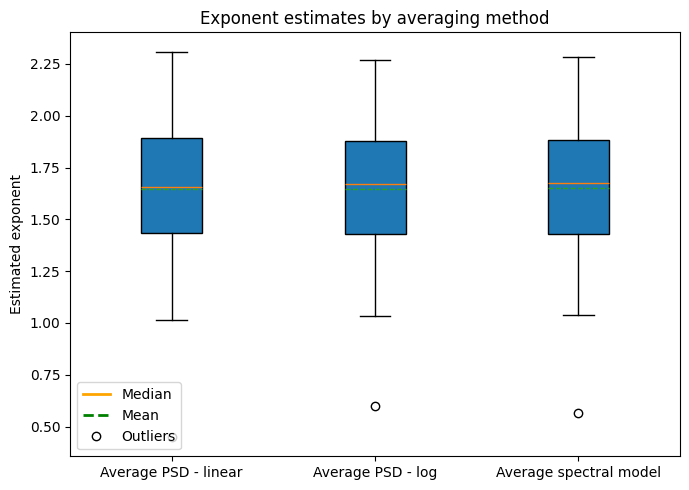

In [12]:
from pathlib import Path

data_dir = Path("/Users/chloe/DissertationSimulations/EEG data")

electrode_sweeps = [
    ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11',
       'E12', 'E13', 'E14', 'E15', 'E16', 'E18', 'E19', 'E20', 'E21',
       'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29', 'E30',
       'E31', 'E32', 'E33', 'E34', 'E35', 'E36', 'E37', 'E38', 'E39',
       'E40', 'E41', 'E42', 'E43', 'E44', 'E45', 'E46', 'E47', 'E50',
       'E51', 'E52', 'E53', 'E54', 'E55', 'E57', 'E58', 'E59', 'E60',
       'E61', 'E62', 'E64', 'E65', 'E66', 'E67', 'E69', 'E70', 'E71',
       'E72', 'E74', 'E75', 'E76', 'E77', 'E78', 'E79', 'E80', 'E82',
       'E83', 'E84', 'E85', 'E86', 'E87', 'E89', 'E90', 'E91', 'E92',
       'E93', 'E95', 'E96', 'E97', 'E98', 'E100', 'E101', 'E102', 'E103',
       'E104', 'E105', 'E106', 'E108', 'E109', 'E110', 'E111', 'E112',
       'E114', 'E115', 'E116', 'E117', 'E118', 'E120', 'E121', 'E122',
       'E123', 'E124', 'Cz']
]

# Average the PSD - linear space
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec",
    psd_average_space = "linear", plot=False, return_full=True
)

exp1b_eeg_result1_psd_linear = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1bresults1_eeg_psd_linear_111elec_full.json", "w") as f:
    json.dump(exp1b_eeg_result1_psd_linear, f, indent=4)

# Average the PSD - log space 
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec",
    psd_average_space = "log", plot=False, return_full=True
)

exp1b_eeg_result2_psd_log = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1bresults2_eeg_psd_log_111elec_full.json", "w") as f:
    json.dump(exp1b_eeg_result2_psd_log, f, indent=4)

# Average the Spectral Model
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec", plot=False, return_full=True
)

exp1b_eeg_result3_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1bresults3_eeg_specmod_111elec_full.json", "w") as f:
    json.dump(exp1b_eeg_result3_specmod, f, indent=4)

# Loading summaries and combining into a single plot
summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1bresults1_eeg_psd_linear_111elec_full.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1bresults2_eeg_psd_log_111elec_full.json", 
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1bresults3_eeg_specmod_111elec_full.json"
]

labels = [
    "Average PSD - linear",
    "Average PSD - log", 
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\EEG data\exp1b_combined_plot_eeg_111elec_full.png", dpi=300, bbox_inches="tight")

In [13]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1bresults1_eeg_psd_linear_111elec_full.json") as f:
    psd_linear_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1bresults2_eeg_psd_log_111elec_full.json") as f:
    psd_log_data = json.load(f)

with open (r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1bresults3_eeg_specmod_111elec_full.json") as f:
    spec_data = json.load(f)

psd_linear = np.array(psd_linear_data["all_distributions"][0])
psd_log = np.array(psd_log_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(psd_linear, psd_log)
print(f"PSD - linear averaging vs PSD - log averaging: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_linear, spec)
print(f"PSD - linear averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_log, spec)
print(f"PSD - log averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

PSD - linear averaging vs PSD - log averaging: t = 0.184, p = 0.85461
PSD - linear averaging vs Spectral model: t = -1.187, p = 0.23796
PSD - log averaging vs Spectral model: t = -2.290, p = 0.02392


#### Experiment 1c
- 2D
- Electrode cluster (5 electrodes) - anterior 
- Average by linear PSD, log PSD and SpecMod.

{'psd_average_space': 'linear'}
{'psd_average_space': 'log'}


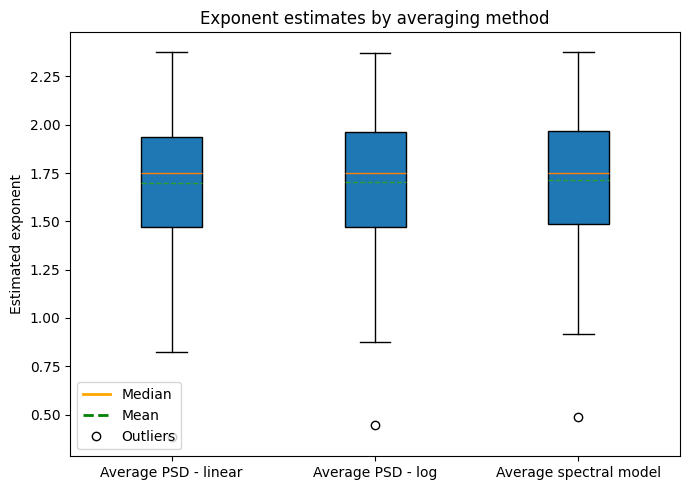

In [16]:
from pathlib import Path

data_dir = Path("/Users/chloe/DissertationSimulations/EEG data")

electrode_sweeps = [
    ["E18", "E10", "E11", "E12", "E5"]
]

# Average the PSD - linear space
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec",
    psd_average_space = "linear", plot=False, return_full=True
)

exp1c_eeg_result1_psd_linear = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1cresults1_eeg_psd_linear_5elec_anterior.json", "w") as f:
    json.dump(exp1c_eeg_result1_psd_linear, f, indent=4)

# Average the PSD - log space 
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec",
    psd_average_space = "log", plot=False, return_full=True
)

exp1c_eeg_result2_psd_log = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1cresults2_eeg_psd_log_5elec_anterior.json", "w") as f:
    json.dump(exp1c_eeg_result2_psd_log, f, indent=4)

# Average the Spectral Model
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec", plot=False, return_full=True
)

exp1c_eeg_result3_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1cresults3_eeg_specmod_5elec_anterior.json", "w") as f:
    json.dump(exp1c_eeg_result3_specmod, f, indent=4)

# Loading summaries and combining into a single plot
summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1cresults1_eeg_psd_linear_5elec_anterior.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1cresults2_eeg_psd_log_5elec_anterior.json", 
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1cresults3_eeg_specmod_5elec_anterior.json"
]

labels = [
    "Average PSD - linear",
    "Average PSD - log", 
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\EEG data\exp1c_combined_plot_eeg_5elec_anterior.png", dpi=300, bbox_inches="tight")

In [17]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1cresults1_eeg_psd_linear_5elec_anterior.json") as f:
    psd_linear_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1cresults2_eeg_psd_log_5elec_anterior.json") as f:
    psd_log_data = json.load(f)

with open (r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1cresults3_eeg_specmod_5elec_anterior.json") as f:
    spec_data = json.load(f)

psd_linear = np.array(psd_linear_data["all_distributions"][0])
psd_log = np.array(psd_log_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(psd_linear, psd_log)
print(f"PSD - linear averaging vs PSD - log averaging: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_linear, spec)
print(f"PSD - linear averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_log, spec)
print(f"PSD - log averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

PSD - linear averaging vs PSD - log averaging: t = -1.344, p = 0.18170
PSD - linear averaging vs Spectral model: t = -4.513, p = 0.00002
PSD - log averaging vs Spectral model: t = -4.181, p = 0.00006


#### Experiment 1d
- 2D
- Electrode cluster (5 electrodes) - posterior
- Average by linear PSD, log PSD and SpecMod.

{'psd_average_space': 'linear'}
{'psd_average_space': 'log'}


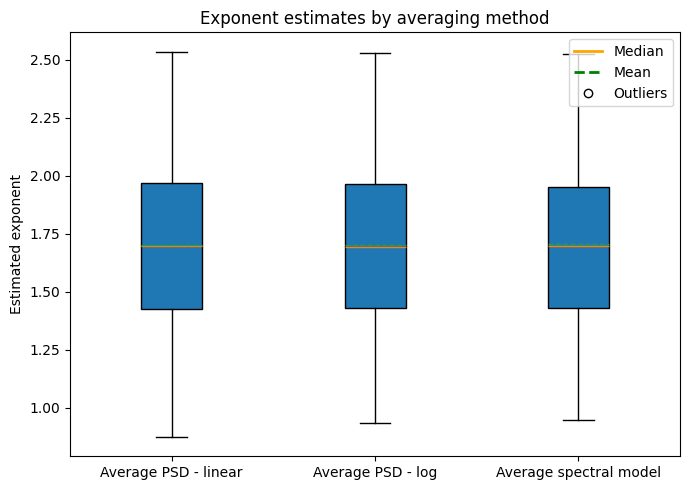

In [18]:
from pathlib import Path

data_dir = Path("/Users/chloe/DissertationSimulations/EEG data")

electrode_sweeps = [
    ["E71", "E76", "E75", "E74", "E82"]
]

# Average the PSD - linear space
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec",
    psd_average_space = "linear", plot=False, return_full=True
)

exp1d_eeg_result1_psd_linear = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1dresults1_eeg_psd_linear_5elec_posterior.json", "w") as f:
    json.dump(exp1d_eeg_result1_psd_linear, f, indent=4)

# Average the PSD - log space 
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec",
    psd_average_space = "log", plot=False, return_full=True
)

exp1d_eeg_result2_psd_log = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1dresults2_eeg_psd_log_5elec_posterior.json", "w") as f:
    json.dump(exp1d_eeg_result2_psd_log, f, indent=4)

# Average the Spectral Model
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec", plot=False, return_full=True
)

exp1d_eeg_result3_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1dresults3_eeg_specmod_5elec_posterior.json", "w") as f:
    json.dump(exp1d_eeg_result3_specmod, f, indent=4)

# Loading summaries and combining into a single plot
summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1dresults1_eeg_psd_linear_5elec_posterior.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1dresults2_eeg_psd_log_5elec_posterior.json", 
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1dresults3_eeg_specmod_5elec_posterior.json"
]

labels = [
    "Average PSD - linear",
    "Average PSD - log", 
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\EEG data\exp1d_combined_plot_eeg_5elec_posterior.png", dpi=300, bbox_inches="tight")

In [19]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1dresults1_eeg_psd_linear_5elec_posterior.json") as f:
    psd_linear_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1dresults2_eeg_psd_log_5elec_posterior.json") as f:
    psd_log_data = json.load(f)

with open (r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1dresults3_eeg_specmod_5elec_posterior.json") as f:
    spec_data = json.load(f)

psd_linear = np.array(psd_linear_data["all_distributions"][0])
psd_log = np.array(psd_log_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(psd_linear, psd_log)
print(f"PSD - linear averaging vs PSD - log averaging: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_linear, spec)
print(f"PSD - linear averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_log, spec)
print(f"PSD - log averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

PSD - linear averaging vs PSD - log averaging: t = -0.064, p = 0.94891
PSD - linear averaging vs Spectral model: t = -1.462, p = 0.14665
PSD - log averaging vs Spectral model: t = -2.182, p = 0.03127


#### Experiment 1e
- 2D
- Electrode cluster (5 electrodes) - lateral
- Average by linear PSD, log PSD and SpecMod.

{'psd_average_space': 'linear'}
{'psd_average_space': 'log'}


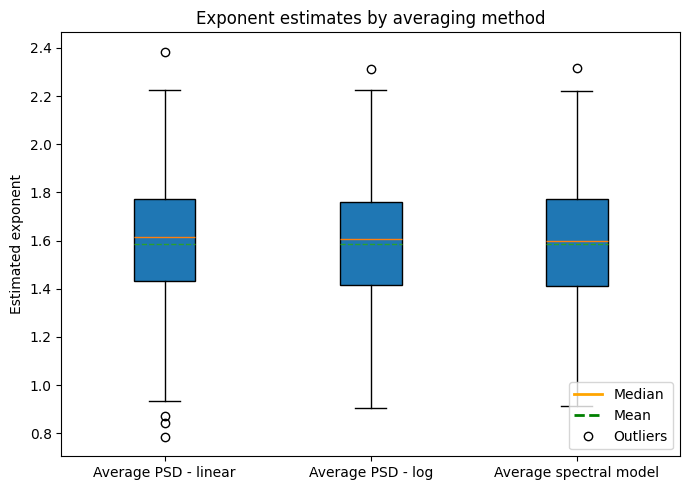

In [21]:
from pathlib import Path

data_dir = Path("/Users/chloe/DissertationSimulations/EEG data")

electrode_sweeps = [
    ["E44", "E40", "E45", "E50", "E57"]
]

# Average the PSD - linear space
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec",
    psd_average_space = "linear", plot=False, return_full=True
)

exp1e_eeg_result1_psd_linear = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1eresults1_eeg_psd_linear_5elec_lateral.json", "w") as f:
    json.dump(exp1e_eeg_result1_psd_linear, f, indent=4)

# Average the PSD - log space 
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_psd_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec",
    psd_average_space = "log", plot=False, return_full=True
)

exp1e_eeg_result2_psd_log = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1eresults2_eeg_psd_log_5elec_lateral.json", "w") as f:
    json.dump(exp1e_eeg_result2_psd_log, f, indent=4)

# Average the Spectral Model
electrodes, means, stds, errors, all_distributions, fig = sweep_electrodes_specmod_2D_eeg(
    electrode_sweeps=electrode_sweeps,
    data_dir=data_dir,
    status="ec", plot=False, return_full=True
)

exp1e_eeg_result3_specmod = {
    "electrodes": electrodes.tolist(),
    "all_distributions": [d.tolist() for d in all_distributions]
}

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1eresults3_eeg_specmod_5elec_lateral.json", "w") as f:
    json.dump(exp1e_eeg_result3_specmod, f, indent=4)

# Loading summaries and combining into a single plot
summary_paths = [
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1eresults1_eeg_psd_linear_5elec_lateral.json",
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1eresults2_eeg_psd_log_5elec_lateral.json", 
    r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1eresults3_eeg_specmod_5elec_lateral.json"
]

labels = [
    "Average PSD - linear",
    "Average PSD - log", 
    "Average spectral model"
]

fig, ax = plot_summary_boxplots(
    summary_paths=summary_paths,
    labels=labels)

fig.savefig(r"C:\Users\chloe\DissertationSimulations\Figures\EEG data\exp1e_combined_plot_eeg_5elec_lateral.png", dpi=300, bbox_inches="tight")

In [22]:
# Paired t-tests
with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1eresults1_eeg_psd_linear_5elec_lateral.json") as f:
    psd_linear_data = json.load(f)

with open(r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1eresults2_eeg_psd_log_5elec_lateral.json") as f:
    psd_log_data = json.load(f)

with open (r"C:\Users\chloe\DissertationSimulations\Result summaries\EEG data\exp1eresults3_eeg_specmod_5elec_lateral.json") as f:
    spec_data = json.load(f)

psd_linear = np.array(psd_linear_data["all_distributions"][0])
psd_log = np.array(psd_log_data["all_distributions"][0])
spec = np.array(spec_data["all_distributions"][0])

t, p = ttest_rel(psd_linear, psd_log)
print(f"PSD - linear averaging vs PSD - log averaging: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_linear, spec)
print(f"PSD - linear averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

t, p = ttest_rel(psd_log, spec)
print(f"PSD - log averaging vs Spectral model: t = {t:.3f}, p = {p:.5f}")

PSD - linear averaging vs PSD - log averaging: t = -0.144, p = 0.88541
PSD - linear averaging vs Spectral model: t = -0.506, p = 0.61369
PSD - log averaging vs Spectral model: t = -0.612, p = 0.54168
